In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

result_folder_path = "/content/drive/MyDrive/TT/benchmark_results/"
DATA_DIR = Path(result_folder_path)

In [3]:
metrics_files = [
    DATA_DIR / "chronos_metrics.csv",
    DATA_DIR / "timesfm_metrics.csv",
    DATA_DIR / "moirai_metrics.csv",
]

dfs = []

for file_path in metrics_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {file_path}")

    df = pd.read_csv(file_path)
    dfs.append(df)

results_df = pd.concat(dfs, ignore_index=True)

display(results_df)

,model,benchmark,MAE,RMSE,MSE,MAPE,sMAPE,n_points,n_series,runtime_seconds,QL_0.1,QL_0.5,QL_0.9
0,Chronos-2,target_only,4.253509,6.147516,37.791956,23.674800,17.841159,182500,500,3.421198,NaN,NaN,NaN
1,Chronos-2,target_future_covariates,0.601773,0.760344,0.578123,2.750393,2.751647,182500,500,21.970497,NaN,NaN,NaN
2,TimesFM-2.5-PyTorch,target_only,8.438385,10.657237,113.576706,35.052028,34.416281,182500,500,234.818417,NaN,NaN,NaN
3,TimesFM-2.5-PyTorch,target_future_covariates,0.195996,0.281331,0.079147,1.066697,1.038168,182500,500,230.505229,NaN,NaN,NaN
4,Moirai-2.0-R-small,target_only,5.212430,6.859036,47.046368,25.412407,21.876668,182500,500,61.246031,1.426852,2.606215,1.275708
5,Moirai-2.0-R-small,target_future_covariates_xreg_residual,0.255896,0.351257,0.123382,1.399781,1.357300,182500,500,65.979456,0.094602,0.127948,0.047567


In [4]:
def get_benchmark_group(benchmark):
    benchmark = str(benchmark)

    if benchmark == "target_only":
        return "target_only"

    if "future_covariates" in benchmark:
        return "target_future_covariates"

    return benchmark


results_df["benchmark_group"] = results_df["benchmark"].apply(get_benchmark_group)

display(results_df)

,model,benchmark,MAE,RMSE,MSE,MAPE,sMAPE,n_points,n_series,runtime_seconds,QL_0.1,QL_0.5,QL_0.9,benchmark_group
0,Chronos-2,target_only,4.253509,6.147516,37.791956,23.674800,17.841159,182500,500,3.421198,NaN,NaN,NaN,target_only
1,Chronos-2,target_future_covariates,0.601773,0.760344,0.578123,2.750393,2.751647,182500,500,21.970497,NaN,NaN,NaN,target_future_covariates
2,TimesFM-2.5-PyTorch,target_only,8.438385,10.657237,113.576706,35.052028,34.416281,182500,500,234.818417,NaN,NaN,NaN,target_only
3,TimesFM-2.5-PyTorch,target_future_covariates,0.195996,0.281331,0.079147,1.066697,1.038168,182500,500,230.505229,NaN,NaN,NaN,target_future_covariates
4,Moirai-2.0-R-small,target_only,5.212430,6.859036,47.046368,25.412407,21.876668,182500,500,61.246031,1.426852,2.606215,1.275708,target_only
5,Moirai-2.0-R-small,target_future_covariates_xreg_residual,0.255896,0.351257,0.123382,1.399781,1.357300,182500,500,65.979456,0.094602,0.127948,0.047567,target_future_covariates


In [5]:
ordered_cols = [
    "model",
    "benchmark",
    "benchmark_group",
    "MAE",
    "MSE",
    "RMSE",
    "MAPE",
    "sMAPE",
    "QL_0.1",
    "QL_0.5",
    "QL_0.9",
    "n_points",
    "n_series",
    "runtime_seconds",
]

ordered_cols = [col for col in ordered_cols if col in results_df.columns]

results_df = results_df[ordered_cols].sort_values(
    ["benchmark_group", "RMSE"],
    ascending=[True, True]
)

display(results_df)

results_df.to_csv(DATA_DIR / "benchmark_results_all_models.csv", index=False)

,model,benchmark,benchmark_group,MAE,MSE,RMSE,MAPE,sMAPE,QL_0.1,QL_0.5,QL_0.9,n_points,n_series,runtime_seconds
3,TimesFM-2.5-PyTorch,target_future_covariates,target_future_covariates,0.195996,0.079147,0.281331,1.066697,1.038168,NaN,NaN,NaN,182500,500,230.505229
5,Moirai-2.0-R-small,target_future_covariates_xreg_residual,target_future_covariates,0.255896,0.123382,0.351257,1.399781,1.357300,0.094602,0.127948,0.047567,182500,500,65.979456
1,Chronos-2,target_future_covariates,target_future_covariates,0.601773,0.578123,0.760344,2.750393,2.751647,NaN,NaN,NaN,182500,500,21.970497
0,Chronos-2,target_only,target_only,4.253509,37.791956,6.147516,23.674800,17.841159,NaN,NaN,NaN,182500,500,3.421198
4,Moirai-2.0-R-small,target_only,target_only,5.212430,47.046368,6.859036,25.412407,21.876668,1.426852,2.606215,1.275708,182500,500,61.246031
2,TimesFM-2.5-PyTorch,target_only,target_only,8.438385,113.576706,10.657237,35.052028,34.416281,NaN,NaN,NaN,182500,500,234.818417


In [6]:
target_only_results = results_df[
    results_df["benchmark_group"] == "target_only"
].sort_values("RMSE")

future_cov_results = results_df[
    results_df["benchmark_group"] == "target_future_covariates"
].sort_values("RMSE")

print("Target-only benchmark:")
display(target_only_results)

print("Target + future covariates benchmark:")
display(future_cov_results)

Target-only benchmark:


,model,benchmark,benchmark_group,MAE,MSE,RMSE,MAPE,sMAPE,QL_0.1,QL_0.5,QL_0.9,n_points,n_series,runtime_seconds
0,Chronos-2,target_only,target_only,4.253509,37.791956,6.147516,23.674800,17.841159,NaN,NaN,NaN,182500,500,3.421198
4,Moirai-2.0-R-small,target_only,target_only,5.212430,47.046368,6.859036,25.412407,21.876668,1.426852,2.606215,1.275708,182500,500,61.246031
2,TimesFM-2.5-PyTorch,target_only,target_only,8.438385,113.576706,10.657237,35.052028,34.416281,NaN,NaN,NaN,182500,500,234.818417


Target + future covariates benchmark:


,model,benchmark,benchmark_group,MAE,MSE,RMSE,MAPE,sMAPE,QL_0.1,QL_0.5,QL_0.9,n_points,n_series,runtime_seconds
3,TimesFM-2.5-PyTorch,target_future_covariates,target_future_covariates,0.195996,0.079147,0.281331,1.066697,1.038168,NaN,NaN,NaN,182500,500,230.505229
5,Moirai-2.0-R-small,target_future_covariates_xreg_residual,target_future_covariates,0.255896,0.123382,0.351257,1.399781,1.357300,0.094602,0.127948,0.047567,182500,500,65.979456
1,Chronos-2,target_future_covariates,target_future_covariates,0.601773,0.578123,0.760344,2.750393,2.751647,NaN,NaN,NaN,182500,500,21.970497


In [7]:
def minmax_score(series, higher_is_better=False):
    s = series.astype(float)

    if s.isna().all():
        return pd.Series([0.0] * len(s), index=s.index)

    s = s.fillna(s.median())

    if s.max() == s.min():
        return pd.Series([1.0] * len(s), index=s.index)

    if higher_is_better:
        return (s - s.min()) / (s.max() - s.min())

    return (s.max() - s) / (s.max() - s.min())

In [8]:
decision = results_df.copy()

decision["mae_score"] = minmax_score(decision["MAE"], higher_is_better=False)
decision["mse_score"] = minmax_score(decision["MSE"], higher_is_better=False)
decision["rmse_score"] = minmax_score(decision["RMSE"], higher_is_better=False)
decision["smape_score"] = minmax_score(decision["sMAPE"], higher_is_better=False)

decision["accuracy_score"] = (
    0.25 * decision["mae_score"] +
    0.25 * decision["mse_score"] +
    0.35 * decision["rmse_score"] +
    0.15 * decision["smape_score"]
)

In [9]:
manual_scores = {
    ("Chronos-2", "target_only"): {
        "covariate_score": 0.30,
        "long_horizon_score": 0.90,
        "ease_score": 0.90,
        "compute_score": 0.80,
        "method_note": "Target-only zero-shot",
    },
    ("Chronos-2", "target_future_covariates"): {
        "covariate_score": 1.00,
        "long_horizon_score": 0.90,
        "ease_score": 0.90,
        "compute_score": 0.80,
        "method_note": "Native future covariates",
    },

    ("TimesFM-2.5-PyTorch", "target_only"): {
        "covariate_score": 0.30,
        "long_horizon_score": 0.90,
        "ease_score": 0.75,
        "compute_score": 0.75,
        "method_note": "Target-only zero-shot",
    },
    ("TimesFM-2.5-PyTorch", "target_future_covariates"): {
        "covariate_score": 0.90,
        "long_horizon_score": 0.90,
        "ease_score": 0.70,
        "compute_score": 0.70,
        "method_note": "forecast_with_covariates / XReg",
    },

    ("Moirai-2.0-R-small", "target_only"): {
        "covariate_score": 0.30,
        "long_horizon_score": 0.85,
        "ease_score": 0.55,
        "compute_score": 0.65,
        "method_note": "Target-only with model.predict",
    },
    ("Moirai-2.0-R-small", "target_future_covariates_xreg_residual"): {
        "covariate_score": 0.70,
        "long_horizon_score": 0.85,
        "ease_score": 0.50,
        "compute_score": 0.60,
        "method_note": "Ridge XReg + Moirai residual",
    },
}

In [10]:
def get_manual_score(row, key):
    return manual_scores.get(
        (row["model"], row["benchmark"]),
        {},
    ).get(key, 0.5)


for col in [
    "covariate_score",
    "long_horizon_score",
    "ease_score",
    "compute_score",
]:
    decision[col] = decision.apply(lambda row: get_manual_score(row, col), axis=1)

decision["method_note"] = decision.apply(
    lambda row: get_manual_score(row, "method_note"),
    axis=1
)

In [11]:
decision["final_score"] = (
    0.50 * decision["accuracy_score"] +
    0.20 * decision["covariate_score"] +
    0.10 * decision["long_horizon_score"] +
    0.10 * decision["ease_score"] +
    0.10 * decision["compute_score"]
)

In [12]:
decision_matrix_cols = [
    "model",
    "benchmark",
    "benchmark_group",
    "method_note",
    "MAE",
    "MSE",
    "RMSE",
    "MAPE",
    "sMAPE",
    "QL_0.1",
    "QL_0.5",
    "QL_0.9",
    "accuracy_score",
    "covariate_score",
    "long_horizon_score",
    "ease_score",
    "compute_score",
    "final_score",
    "runtime_seconds",
    "n_points",
    "n_series",
]

decision_matrix_cols = [
    col for col in decision_matrix_cols
    if col in decision.columns
]

decision_matrix = decision[decision_matrix_cols].sort_values(
    "final_score",
    ascending=False
)

display(decision_matrix)

decision_matrix.to_csv(DATA_DIR / "model_selection_decision_matrix.csv", index=False)

,model,benchmark,benchmark_group,method_note,MAE,MSE,RMSE,MAPE,sMAPE,QL_0.1,...,QL_0.9,accuracy_score,covariate_score,long_horizon_score,ease_score,compute_score,final_score,runtime_seconds,n_points,n_series
1,Chronos-2,target_future_covariates,target_future_covariates,Native future covariates,0.601773,0.578123,0.760344,2.750393,2.751647,NaN,...,NaN,0.962735,1.0,0.90,0.90,0.80,0.941367,21.970497,182500,500
3,TimesFM-2.5-PyTorch,target_future_covariates,target_future_covariates,forecast_with_covariates / XReg,0.195996,0.079147,0.281331,1.066697,1.038168,NaN,...,NaN,1.000000,0.9,0.90,0.70,0.70,0.910000,230.505229,182500,500
5,Moirai-2.0-R-small,target_future_covariates_xreg_residual,target_future_covariates,Ridge XReg + Moirai residual,0.255896,0.123382,0.351257,1.399781,1.357300,0.094602,...,0.047567,0.994293,0.7,0.85,0.50,0.60,0.832146,65.979456,182500,500
0,Chronos-2,target_only,target_only,Target-only zero-shot,4.253509,37.791956,6.147516,23.674800,17.841159,NaN,...,NaN,0.520472,0.3,0.90,0.90,0.80,0.580236,3.421198,182500,500
4,Moirai-2.0-R-small,target_only,target_only,Target-only with model.predict,5.212430,47.046368,6.859036,25.412407,21.876668,1.426852,...,1.275708,0.428866,0.3,0.85,0.55,0.65,0.479433,61.246031,182500,500
2,TimesFM-2.5-PyTorch,target_only,target_only,Target-only zero-shot,8.438385,113.576706,10.657237,35.052028,34.416281,NaN,...,NaN,0.000000,0.3,0.90,0.75,0.75,0.300000,234.818417,182500,500


In [13]:
best_row = decision_matrix.iloc[0]

print("Chosen base model:", best_row["model"])
print("Benchmark:", best_row["benchmark"])
print("Method:", best_row["method_note"])
print("Final score:", best_row["final_score"])
print("MAE:", best_row["MAE"])
print("MSE:", best_row["MSE"])
print("RMSE:", best_row["RMSE"])
print("MAPE:", best_row["MAPE"])
print("sMAPE:", best_row["sMAPE"])

Chosen base model: Chronos-2
Benchmark: target_future_covariates
Method: Native future covariates
Final score: 0.9413674604979005
MAE: 0.6017726192694975
MSE: 0.5781230659813644
RMSE: 0.7603440444833933
MAPE: 2.7503929916620384
sMAPE: 2.751646571482955


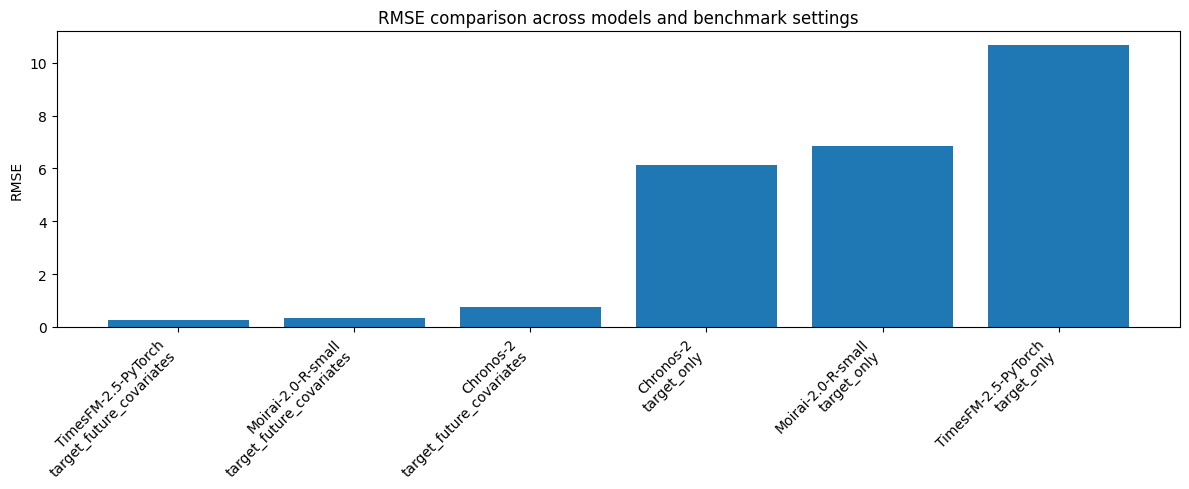

In [14]:
plot_df = results_df.copy()
plot_df["label"] = plot_df["model"] + "\n" + plot_df["benchmark_group"]

plt.figure(figsize=(12, 5))
plt.bar(plot_df["label"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("RMSE comparison across models and benchmark settings")
plt.tight_layout()
plt.show()

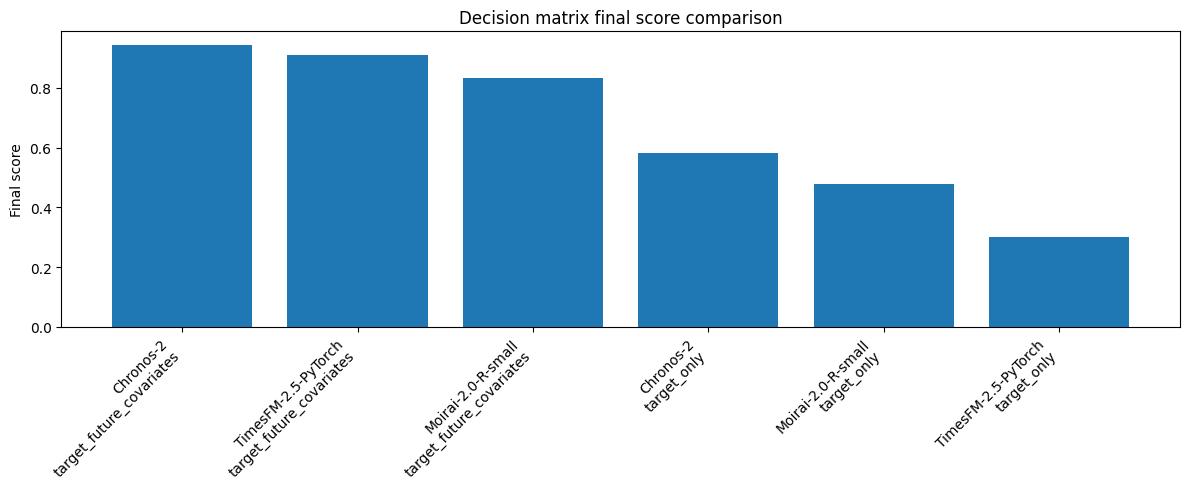

In [15]:
plot_df = decision_matrix.copy()
plot_df["label"] = plot_df["model"] + "\n" + plot_df["benchmark_group"]

plt.figure(figsize=(12, 5))
plt.bar(plot_df["label"], plot_df["final_score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Final score")
plt.title("Decision matrix final score comparison")
plt.tight_layout()
plt.show()